In [44]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.316633,0.019739,-0.482612,0.775370,0.948201,0
1,-1.129235,-3.098122,1.955555,2.392612,1.628362,1
2,-0.265424,-1.102191,-2.907409,-0.667830,0.124539,0
3,-0.320287,-0.689974,0.706306,1.130485,0.375710,1
4,-0.769330,-0.826949,-0.828355,0.879998,1.819009,0


In [4]:
#now creating a function which will take samples from rows

# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [49]:
#takes samples from columns only
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df.loc[:, cols].copy()
  new_df['target'] = df['target']

  return new_df

In [6]:
#takes combined samples
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

# Row Sampling

In [23]:
df1 = sample_rows(df,0.1)  #we willl only 10 rows of our original data of 100 rows

In [24]:
df2 = sample_rows(df,0.1)

In [25]:
df3 = sample_rows(df,0.1) #we generated 3 datasets for 3 decision tress

In [26]:
df1.shape

(10, 6)

In [27]:
df2.shape

(10, 6)

In [28]:
df3.shape

(10, 6)

In [29]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [30]:
#now training all three datasets
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

DecisionTreeClassifier()

In [31]:
from sklearn.tree import plot_tree

[Text(0.4, 0.875, 'x[0] <= -0.785\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 0.875\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[1] <= 0.235\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]')]

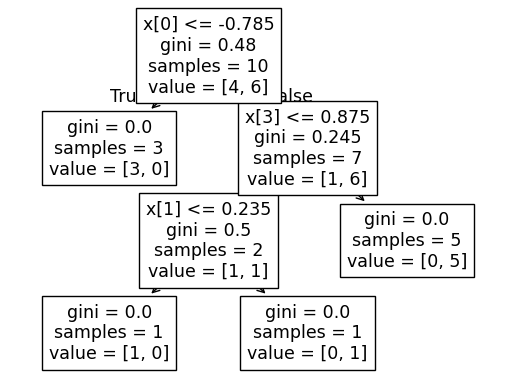

In [32]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[0] <= -0.246\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

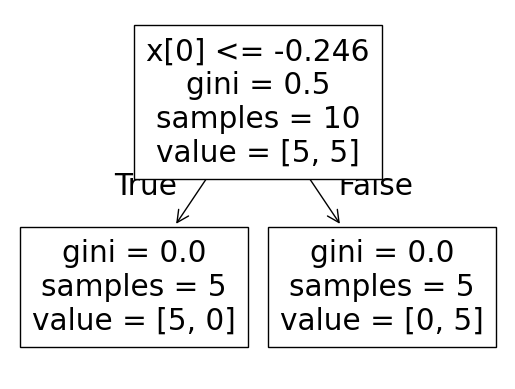

In [33]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[1] <= 0.111\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.625, 0.5, '  False')]

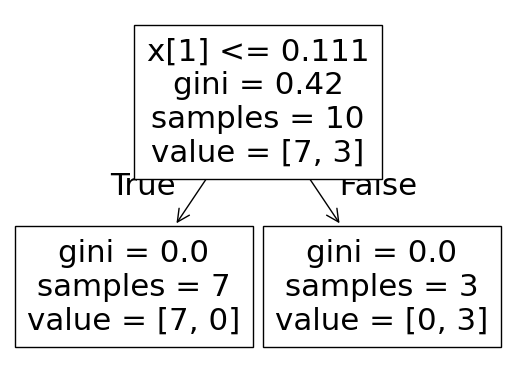

In [34]:
plot_tree(clf3)

In [35]:
#now predicting the new point which comes

In [38]:
clf1.predict(np.array([0.316633,	0.019739,	-0.482612,	0.775370	]).reshape(1,4))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [39]:
clf2.predict(np.array([0.316633,	0.019739,	-0.482612,	0.775370	]).reshape(1,4))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [40]:
clf3.predict(np.array([0.316633,	0.019739,	-0.482612,	0.775370	]).reshape(1,4))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

# Columns Sampling

In [50]:
df1 = sample_features(df,0.8)

In [51]:
df2 = sample_features(df,0.8)

In [52]:
df3 = sample_features(df,0.8)

In [53]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [54]:
df1.shape

(100, 5)

In [55]:
#now training all three datasets
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5108695652173914, 0.9375, 'x[0] <= -0.387\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.32608695652173914, 0.8125, 'x[0] <= -0.703\ngini = 0.231\nsamples = 45\nvalue = [39, 6]'),
 Text(0.41847826086956524, 0.875, 'True  '),
 Text(0.21739130434782608, 0.6875, 'x[2] <= 0.575\ngini = 0.149\nsamples = 37\nvalue = [34, 3]'),
 Text(0.13043478260869565, 0.5625, 'x[2] <= -2.213\ngini = 0.062\nsamples = 31\nvalue = [30, 1]'),
 Text(0.08695652173913043, 0.4375, 'x[2] <= -2.274\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.043478260869565216, 0.3125, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.13043478260869565, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.17391304347826086, 0.4375, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]'),
 Text(0.30434782608695654, 0.5625, 'x[0] <= -1.624\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.2608695652173913, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.34782608695652173, 0.4375, 'x[3] <= 2.101

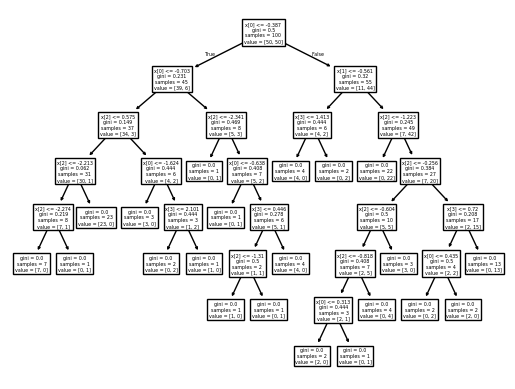

In [56]:
plot_tree(clf1)

[Text(0.5108695652173914, 0.9375, 'x[2] <= -0.387\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.32608695652173914, 0.8125, 'x[2] <= -0.703\ngini = 0.231\nsamples = 45\nvalue = [39, 6]'),
 Text(0.41847826086956524, 0.875, 'True  '),
 Text(0.21739130434782608, 0.6875, 'x[1] <= 0.575\ngini = 0.149\nsamples = 37\nvalue = [34, 3]'),
 Text(0.13043478260869565, 0.5625, 'x[1] <= -2.213\ngini = 0.062\nsamples = 31\nvalue = [30, 1]'),
 Text(0.08695652173913043, 0.4375, 'x[1] <= -2.274\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.043478260869565216, 0.3125, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.13043478260869565, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.17391304347826086, 0.4375, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]'),
 Text(0.30434782608695654, 0.5625, 'x[2] <= -1.624\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.2608695652173913, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.34782608695652173, 0.4375, 'x[1] <= 2.031

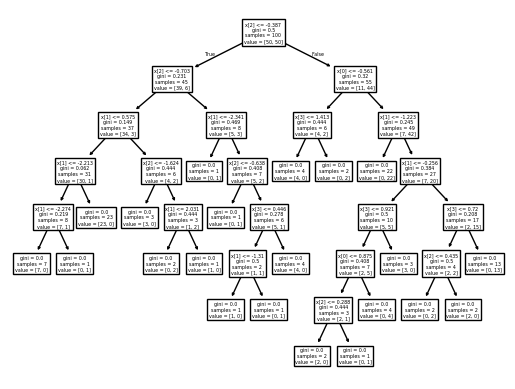

In [57]:
plot_tree(clf2)

[Text(0.42857142857142855, 0.95, 'x[2] <= -0.387\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.21428571428571427, 0.85, 'x[1] <= 1.055\ngini = 0.231\nsamples = 45\nvalue = [39, 6]'),
 Text(0.3214285714285714, 0.8999999999999999, 'True  '),
 Text(0.14285714285714285, 0.75, 'x[2] <= -1.5\ngini = 0.201\nsamples = 44\nvalue = [39, 5]'),
 Text(0.07142857142857142, 0.65, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.21428571428571427, 0.65, 'x[3] <= 3.401\ngini = 0.311\nsamples = 26\nvalue = [21, 5]'),
 Text(0.14285714285714285, 0.55, 'x[2] <= -1.447\ngini = 0.269\nsamples = 25\nvalue = [21, 4]'),
 Text(0.07142857142857142, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21428571428571427, 0.45, 'x[3] <= 0.968\ngini = 0.219\nsamples = 24\nvalue = [21, 3]'),
 Text(0.14285714285714285, 0.35, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.2857142857142857, 0.35, 'x[3] <= 2.104\ngini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.14285714285714285, 0.25, 'x[1

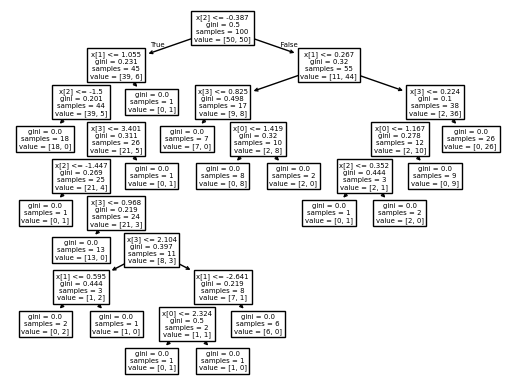

In [58]:
plot_tree(clf3)

In [60]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col4', 'col3', 'col5', 'target'], dtype='object')
Index(['col4', 'col3', 'col1', 'col5', 'target'], dtype='object')
Index(['col5', 'col2', 'col1', 'col4', 'target'], dtype='object')


In [61]:
df3.head()

,col5,col2,col1,col4,target
0,0.948201,0.019739,0.316633,0.775370,0
1,1.628362,-3.098122,-1.129235,2.392612,1
2,0.124539,-1.102191,-0.265424,-0.667830,0
3,0.375710,-0.689974,-0.320287,1.130485,1
4,1.819009,-0.826949,-0.769330,0.879998,0


In [63]:
clf1.predict(np.array([0.948201,	0.019739,	0.316633,	0.775370	]).reshape(1,4))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [64]:
clf2.predict(np.array([0.948201,	0.019739,	0.316633,	0.775370	]).reshape(1,4))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [65]:
clf3.predict(np.array([0.948201,	0.019739,	0.316633,	0.775370	]).reshape(1,4))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

# Combined sampling

In [66]:
df1 = combined_sampling(df,0.5,0.5)

In [67]:
df2 = combined_sampling(df,0.5,0.5)

In [68]:
df3 = combined_sampling(df,0.5,0.5)

In [69]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col3', 'target'], dtype='object')
Index(['col1', 'col2', 'target'], dtype='object')
Index(['col5', 'col2', 'target'], dtype='object')


In [73]:
df3.head()

,col5,col2,target
89,1.541033,2.227719,1
55,0.893813,1.124919,1
21,0.594532,0.831032,1
8,-1.044780,1.743677,1
78,-0.317591,2.667095,1


In [74]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [75]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.55625, 0.9285714285714286, 'x[1] <= -0.224\ngini = 0.471\nsamples = 50\nvalue = [31, 19]'),
 Text(0.2625, 0.7857142857142857, 'x[1] <= -2.878\ngini = 0.394\nsamples = 37\nvalue = [27, 10]'),
 Text(0.40937500000000004, 0.8571428571428572, 'True  '),
 Text(0.1, 0.6428571428571429, 'x[0] <= -1.619\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.05, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.15, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.425, 0.6428571428571429, 'x[0] <= 0.558\ngini = 0.334\nsamples = 33\nvalue = [26, 7]'),
 Text(0.25, 0.5, 'x[0] <= -0.458\ngini = 0.111\nsamples = 17\nvalue = [16, 1]'),
 Text(0.2, 0.35714285714285715, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.3, 0.35714285714285715, 'x[0] <= -0.369\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.25, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.35, 0.21428571428571427, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.6, 0.5, 'x[0] <= 1.

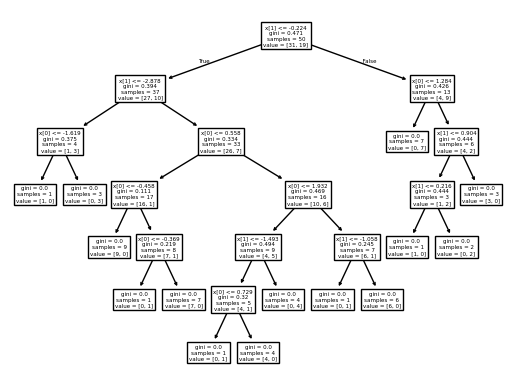

In [76]:
plot_tree(clf1)

[Text(0.4230769230769231, 0.9166666666666666, 'x[1] <= 0.111\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.15384615384615385, 0.75, 'x[1] <= -0.726\ngini = 0.211\nsamples = 25\nvalue = [22, 3]'),
 Text(0.28846153846153844, 0.8333333333333333, 'True  '),
 Text(0.07692307692307693, 0.5833333333333334, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.23076923076923078, 0.5833333333333334, 'x[1] <= -0.446\ngini = 0.444\nsamples = 9\nvalue = [6, 3]'),
 Text(0.15384615384615385, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.3076923076923077, 0.4166666666666667, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.6923076923076923, 0.75, 'x[0] <= -0.576\ngini = 0.269\nsamples = 25\nvalue = [4, 21]'),
 Text(0.5576923076923077, 0.8333333333333333, '  False'),
 Text(0.5384615384615384, 0.5833333333333334, 'x[1] <= 0.528\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),


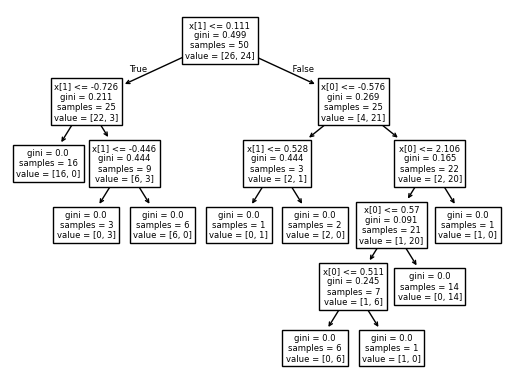

In [77]:
plot_tree(clf2)

[Text(0.36363636363636365, 0.9285714285714286, 'x[1] <= -0.741\ngini = 0.48\nsamples = 50\nvalue = [20, 30]'),
 Text(0.2727272727272727, 0.7857142857142857, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.3181818181818182, 0.8571428571428572, 'True  '),
 Text(0.45454545454545453, 0.7857142857142857, 'x[1] <= 0.267\ngini = 0.278\nsamples = 36\nvalue = [6, 30]'),
 Text(0.40909090909090906, 0.8571428571428572, '  False'),
 Text(0.2727272727272727, 0.6428571428571429, 'x[0] <= 0.954\ngini = 0.494\nsamples = 9\nvalue = [4, 5]'),
 Text(0.18181818181818182, 0.5, 'x[1] <= -0.496\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.09090909090909091, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2727272727272727, 0.35714285714285715, 'x[1] <= 0.078\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.18181818181818182, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.36363636363636365, 0.21428571428571427, 'x[1] <= 0.19\ngini = 0.5\nsamp

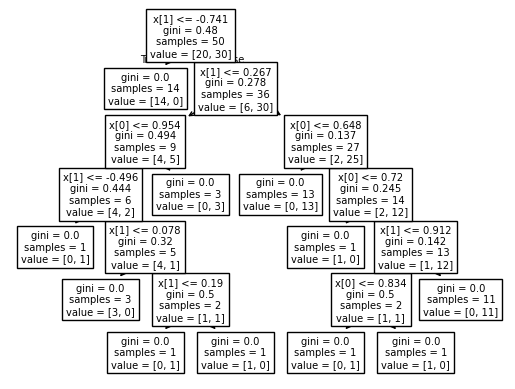

In [78]:
plot_tree(clf3)

In [79]:
clf1.predict(np.array([1.541033,	2.227719]).reshape(1,2))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [80]:
clf2.predict(np.array([1.541033,	2.227719]).reshape(1,2))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [81]:
clf3.predict(np.array([1.541033,	2.227719]).reshape(1,2))

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])